# Análisis de Radiancia Terrestre — DSCOVR/NISTAR (Septiembre/Agosto 2025)
## Módulo 6.1 · Proyecto de Análisis de Datos
**Alumno:** Alejandro Cabrera Barea
**Fecha:** Abril 2025  
**Dataset:** NIST Level 1B — `nist_1b_202501_filtered_03.h5`  
**Fuente oficial:** [NASA DSCOVR Science Gateway](https://www.nesdis.noaa.gov/our-satellites/currently-flying/dscovr)

---
### Descripción del proyecto
Este notebook analiza mediciones de **radiancia terrestre** captadas por el instrumento NISTAR (National Institute of Standards and Technology Advanced Radiometer) a bordo del satélite DSCOVR, situado en el punto de Lagrange L1.  
El archivo HDF5 contiene tres bandas espectrales del mes de agosto y septiembre de 2025:
- **Banda A (Total):** radiancia integrada en todo el espectro visible e infrarrojo.
- **Banda B (Shortwave):** luz solar reflejada por nubes, hielo, océanos y continentes.
- **Banda C (NIR):** emisión infrarroja cercana, relacionada con la actividad de la vegetación.

**Hipótesis de análisis:**
1. La radiancia total (A) sigue un patrón temporal con variaciones diurnas detectables.
2. La Banda B presenta mayor variabilidad que la Banda C debido a la cobertura nubosa.
3. Existe correlación positiva entre las Bandas A y B, pero débil con la Banda C.
4. Los valores interpolados no difieren estadísticamente de los valores reales.

## 1. Importación de librerías

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import h5py
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✓ Librerías cargadas correctamente")
print(f"  NumPy  : {np.__version__}")
print(f"  Pandas : {pd.__version__}")

✓ Librerías cargadas correctamente
  NumPy  : 2.4.4
  Pandas : 3.0.2


## 2. Lectura y estructura del dataset
El archivo `.h5` se organiza en grupos HDF5 bajo la ruta `Earth_Radiance_Filtered/`.  
Se cargan las tres bandas en DataFrames independientes usando una función auxiliar reutilizable.

In [11]:
BASE_DIR = Path.cwd()
if not (BASE_DIR / "Files").exists():
    # Si el notebook se ejecuta desde `Jupyter`, sube al directorio del proyecto.
    BASE_DIR = BASE_DIR.parent

FILE_PATH = BASE_DIR / "Files" / "nist_1b_202501_filtered_03.h5"

if not FILE_PATH.exists():
    raise FileNotFoundError(f"No se encontro el archivo HDF5: {FILE_PATH}")


def cargar_banda(file_path, band_path, include_lunar=False):
    """Carga una banda espectral del archivo HDF5 en un DataFrame de Pandas."""
    with h5py.File(file_path, "r") as f:
        dset = f[band_path]

        time     = np.array(dset["DSCOVREpochTime"][:], dtype=np.float64)
        radiance = dset["EarthRadiance"][:]
        radiance = radiance.byteswap().view(radiance.dtype.newbyteorder("="))
        interp   = np.array(dset["isInterpolated"][:])

        data = {"Time": time, "Radiance": radiance, "Is_Interpolated": interp}

        if include_lunar:
            lunar = dset["LunarCorrection"][:]
            data["LunarCorrection"] = lunar.byteswap().view(lunar.dtype.newbyteorder("="))

    return pd.DataFrame(data)


In [12]:
# Cargar las tres bandas
df_A = cargar_banda(FILE_PATH, "Earth_Radiance_Filtered/Band A (Total)")
df_B = cargar_banda(FILE_PATH, "Earth_Radiance_Filtered/Band B (Shortwave)", include_lunar=True)
df_C = cargar_banda(FILE_PATH, "Earth_Radiance_Filtered/Band C (NIR)")

# Convertir timestamps UNIX a datetime
for df in [df_A, df_B, df_C]:
    df["Datetime"] = pd.to_datetime(df["Time"], unit="s")

print(f"Banda A: {len(df_A):,} observaciones")
print(f"Banda B: {len(df_B):,} observaciones")
print(f"Banda C: {len(df_C):,} observaciones")

Banda A: 194,418 observaciones
Banda B: 247,739 observaciones
Banda C: 194,418 observaciones


## 3. Inspección inicial de los datos

In [13]:
print("=== Banda A — primeras filas ===")
print(df_A.head())
print()
print("=== info() ===")
df_A.info()

=== Banda A — primeras filas ===
           Time  Radiance  Is_Interpolated            Datetime
0  1.786453e+09    183.08                0 2026-08-11 12:58:30
1  1.786453e+09    183.09                0 2026-08-11 12:58:40
2  1.786453e+09    183.09                0 2026-08-11 12:58:50
3  1.786453e+09    183.09                0 2026-08-11 12:59:00
4  1.786453e+09    183.09                0 2026-08-11 12:59:10

=== info() ===
<class 'pandas.DataFrame'>
RangeIndex: 194418 entries, 0 to 194417
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype        
---  ------           --------------   -----        
 0   Time             194418 non-null  float64      
 1   Radiance         194418 non-null  float64      
 2   Is_Interpolated  194418 non-null  uint8        
 3   Datetime         194418 non-null  datetime64[s]
dtypes: datetime64[s](1), float64(2), uint8(1)
memory usage: 4.6 MB


In [27]:
print("=== describe() — Banda A ===")
df_A[["Radiance"]].describe().round(2)

=== describe() — Banda A ===


,Radiance
count,194418.00
mean,175.60
std,3.85
min,160.43
25%,173.21
50%,176.06
75%,178.17
max,184.99


In [15]:
# Rango temporal
print(f"Período cubierto:")
print(f"  Inicio : {df_A['Datetime'].min()}")
print(f"  Fin    : {df_A['Datetime'].max()}")
print(f"  Duración: {(df_A['Datetime'].max() - df_A['Datetime'].min()).days} días")

Período cubierto:
  Inicio : 2026-08-11 12:58:30
  Fin    : 2026-09-11 11:59:52
  Duración: 30 días


## 4. Limpieza de datos (Data Cleaning)
Se gestionan: valores nulos, duplicados, valores físicamente imposibles (negativos) y se etiquetan los registros interpolados.

In [16]:
def limpiar_banda(df, nombre):
    """Pipeline de limpieza para una banda espectral."""
    n_orig = len(df)
    
    # 1. Eliminar duplicados
    df = df.drop_duplicates(subset="Time")
    n_dup = n_orig - len(df)
    
    # 2. Eliminar NaN en Radiance
    df = df.dropna(subset=["Radiance"])
    n_nan = n_orig - n_dup - len(df)
    
    # 3. Eliminar valores físicamente imposibles (negativos)
    n_antes = len(df)
    df = df[df["Radiance"] >= 0].copy()
    n_neg = n_antes - len(df)
    
    # 4. Ordenar por tiempo
    df = df.sort_values("Datetime").reset_index(drop=True)
    
    print(f"[{nombre}] {n_orig:,} → {len(df):,} filas | "
          f"Duplicados: {n_dup} | NaN: {n_nan} | Negativos: {n_neg} | "
          f"Interpolados: {df['Is_Interpolated'].sum():,}")
    return df

df_A = limpiar_banda(df_A, "Banda A")
df_B = limpiar_banda(df_B, "Banda B")
df_C = limpiar_banda(df_C, "Banda C")

[Banda A] 194,418 → 194,418 filas | Duplicados: 0 | NaN: 0 | Negativos: 0 | Interpolados: 2,813
[Banda B] 247,739 → 247,739 filas | Duplicados: 0 | NaN: 0 | Negativos: 0 | Interpolados: 68,307
[Banda C] 194,418 → 194,418 filas | Duplicados: 0 | NaN: 0 | Negativos: 0 | Interpolados: 2,813


## 5. Manipulación avanzada con NumPy y Pandas
Se crean columnas derivadas y se realizan agrupaciones temporales para condensar la serie horaria.

In [17]:
# ── Columnas calculadas con NumPy ──────────────────────────────────────
for df, nombre in [(df_A,"A"), (df_B,"B"), (df_C,"C")]:
    # Z-score (normalización estadística)
    df["Radiance_zscore"] = (df["Radiance"] - df["Radiance"].mean()) / df["Radiance"].std()
    # Anomalía respecto a la media
    df["Anomalia"] = df["Radiance"] - df["Radiance"].mean()
    # Indicador binario de outlier (|z| > 3)
    df["Es_outlier"] = np.abs(df["Radiance_zscore"]) > 3

print("Columnas en df_A:", list(df_A.columns))
print()
print("Outliers detectados:")
print(f"  Banda A: {df_A['Es_outlier'].sum()}")
print(f"  Banda B: {df_B['Es_outlier'].sum()}")
print(f"  Banda C: {df_C['Es_outlier'].sum()}")

Columnas en df_A: ['Time', 'Radiance', 'Is_Interpolated', 'Datetime', 'Radiance_zscore', 'Anomalia', 'Es_outlier']

Outliers detectados:
  Banda A: 846
  Banda B: 1893
  Banda C: 884


In [18]:
# ── Resampleo horario (groupby temporal con Pandas) ─────────────────────
def resampleo_horario(df):
    return (df.set_index("Datetime")["Radiance"]
              .resample("1h")
              .agg(["mean","std","min","max","count"])
              .rename(columns={"mean":"Media","std":"Desv","min":"Min","max":"Max","count":"N"})
              .reset_index())

hourly_A = resampleo_horario(df_A)
hourly_B = resampleo_horario(df_B)
hourly_C = resampleo_horario(df_C)

# ── Dataset combinado para correlaciones ────────────────────────────────
df_combo = (hourly_A[["Datetime","Media"]].rename(columns={"Media":"Banda_A"})
            .merge(hourly_B[["Datetime","Media"]].rename(columns={"Media":"Banda_B"}), on="Datetime")
            .merge(hourly_C[["Datetime","Media"]].rename(columns={"Media":"Banda_C"}), on="Datetime")
            .dropna())

print("Dataset combinado (resampleo horario):")
print(df_combo.head())
print(f"\nForma: {df_combo.shape}")

Dataset combinado (resampleo horario):
             Datetime     Banda_A    Banda_B    Banda_C
0 2026-08-11 12:00:00  183.094444  83.443472  36.394444
1 2026-08-11 13:00:00  183.708500  84.968194  36.618711
2 2026-08-11 14:00:00  184.799889  86.562139  36.679439
3 2026-08-11 15:00:00  184.414694  87.458472  35.873178
4 2026-08-11 16:00:00  182.042167  87.130222  34.542700

Forma: (592, 4)


In [30]:
# ── Estadísticas por semana (groupby) ───────────────────────────────────
df_A["Semana"] = df_A["Datetime"].dt.isocalendar().week.astype(int)
stats_semana = df_A.groupby("Semana")["Radiance"].agg(["mean","std","median"]).round(6)
print("Estadísticas de Banda A por semana:")
print(stats_semana)

Estadísticas de Banda A por semana:
              mean       std  median
Semana                              
33      176.791822  3.324108  176.40
34      177.566684  2.270949  177.28
35      175.507356  4.047637  176.08
36      174.642167  3.877416  174.86
37      172.702822  3.868542  173.64


## 6. Visualización de resultados
Se generan cuatro gráficos que permiten extraer conclusiones visuales del dataset.

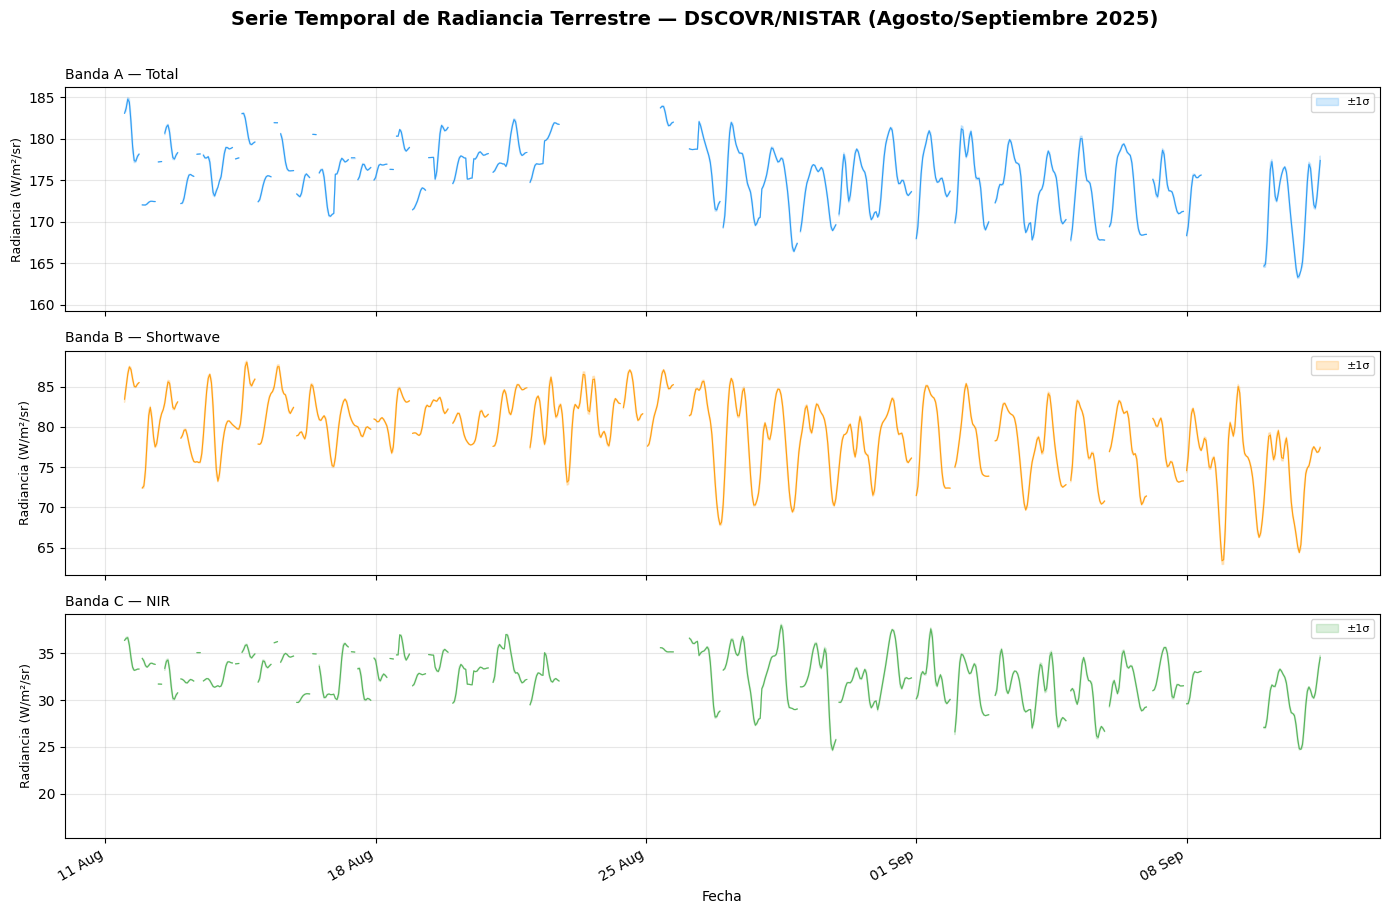

✓ Gráfico 1 guardado


In [28]:
# ── GRÁFICO 1: Serie temporal de las tres bandas ─────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle("Serie Temporal de Radiancia Terrestre — DSCOVR/NISTAR (Agosto/Septiembre 2025)",
             fontsize=14, fontweight="bold", y=1.01)

config = [
    (hourly_A, "Banda A — Total",     "#2196F3"),
    (hourly_B, "Banda B — Shortwave", "#FF9800"),
    (hourly_C, "Banda C — NIR",       "#4CAF50"),
]

for ax, (df_h, title, color) in zip(axes, config):
    ax.plot(df_h["Datetime"], df_h["Media"], color=color, linewidth=0.8, alpha=0.9)
    ax.fill_between(df_h["Datetime"],
                    df_h["Media"] - df_h["Desv"],
                    df_h["Media"] + df_h["Desv"],
                    color=color, alpha=0.2, label="±1σ")
    ax.set_ylabel("Radiancia (W/m²/sr)", fontsize=9)
    ax.set_title(title, fontsize=10, loc="left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Fecha", fontsize=10)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("grafico1_serie_temporal.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Gráfico 1 guardado")

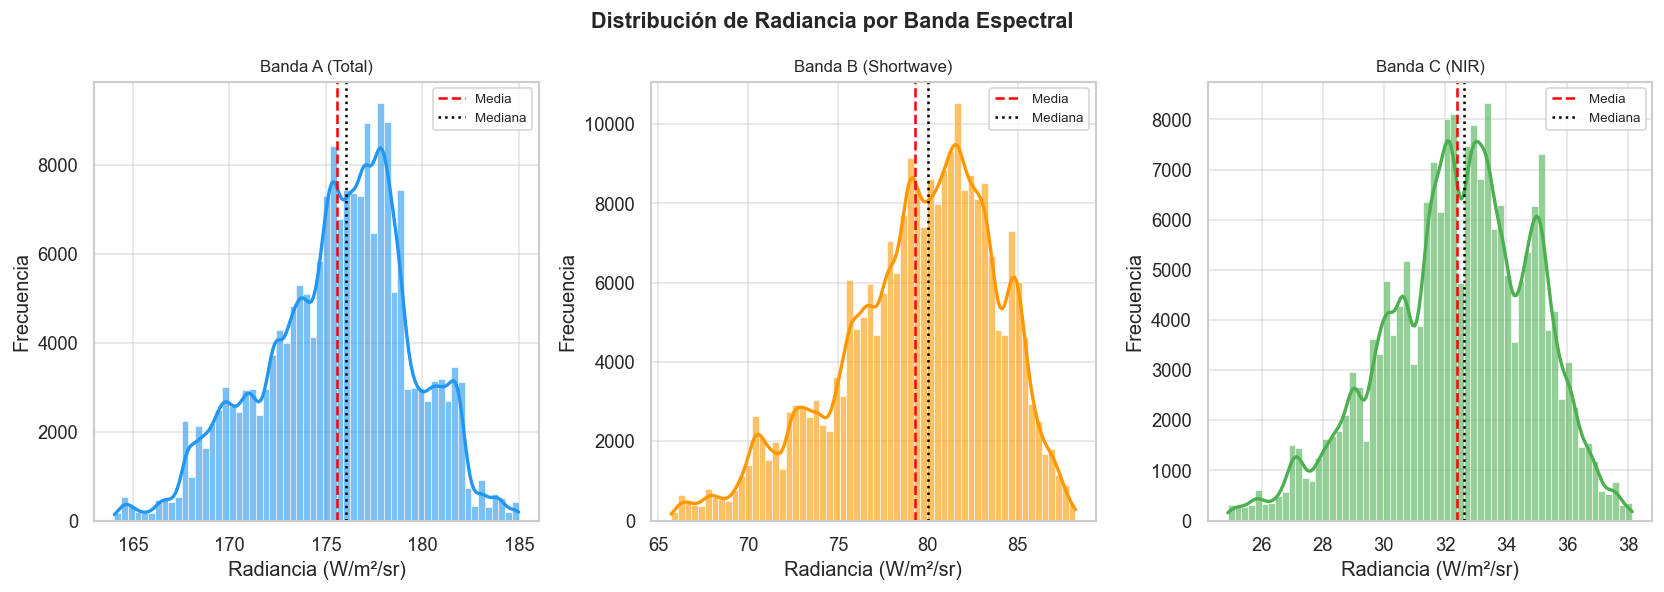

✓ Gráfico 2 guardado


In [21]:
# ── GRÁFICO 2: Distribución de radiancia (Histogramas + KDE) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Distribución de Radiancia por Banda Espectral", fontsize=13, fontweight="bold")

datos = [(df_A, "Banda A (Total)",     "#2196F3"),
         (df_B, "Banda B (Shortwave)", "#FF9800"),
         (df_C, "Banda C (NIR)",       "#4CAF50")]

for ax, (df, title, color) in zip(axes, datos):
    sns.histplot(df[~df["Es_outlier"]]["Radiance"], ax=ax,
                 kde=True, color=color, bins=60, alpha=0.6,
                 line_kws={"linewidth": 2})
    ax.axvline(df["Radiance"].mean(),   color="red",  linestyle="--", linewidth=1.5, label=f"Media")
    ax.axvline(df["Radiance"].median(), color="black",linestyle=":",  linewidth=1.5, label=f"Mediana")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Radiancia (W/m²/sr)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("grafico2_histogramas.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Gráfico 2 guardado")

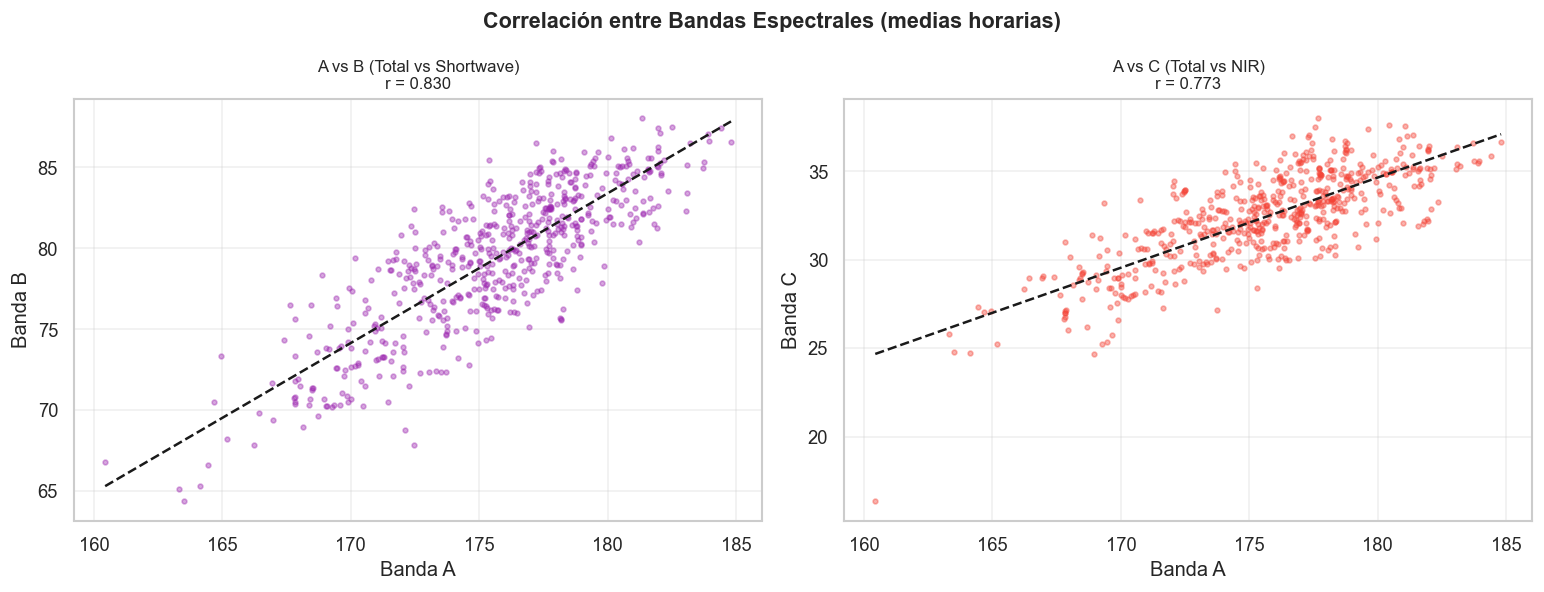

✓ Gráfico 3 guardado


In [22]:
# ── GRÁFICO 3: Scatter plots de correlación entre bandas ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Correlación entre Bandas Espectrales (medias horarias)", fontsize=13, fontweight="bold")

pares = [
    ("Banda_A", "Banda_B", "A vs B (Total vs Shortwave)", "#9C27B0"),
    ("Banda_A", "Banda_C", "A vs C (Total vs NIR)",       "#F44336"),
]

for ax, (x_col, y_col, title, color) in zip(axes, pares):
    ax.scatter(df_combo[x_col], df_combo[y_col],
               alpha=0.4, s=8, color=color)
    # Línea de tendencia
    z = np.polyfit(df_combo[x_col].dropna(), df_combo[y_col].dropna(), 1)
    p = np.poly1d(z)
    xs = np.linspace(df_combo[x_col].min(), df_combo[x_col].max(), 200)
    ax.plot(xs, p(xs), "k--", linewidth=1.5)
    
    corr = df_combo[[x_col, y_col]].corr().iloc[0, 1]
    ax.set_title(f"{title}\nr = {corr:.3f}", fontsize=10)
    ax.set_xlabel(x_col.replace("_", " "))
    ax.set_ylabel(y_col.replace("_", " "))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("grafico3_scatter.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Gráfico 3 guardado")

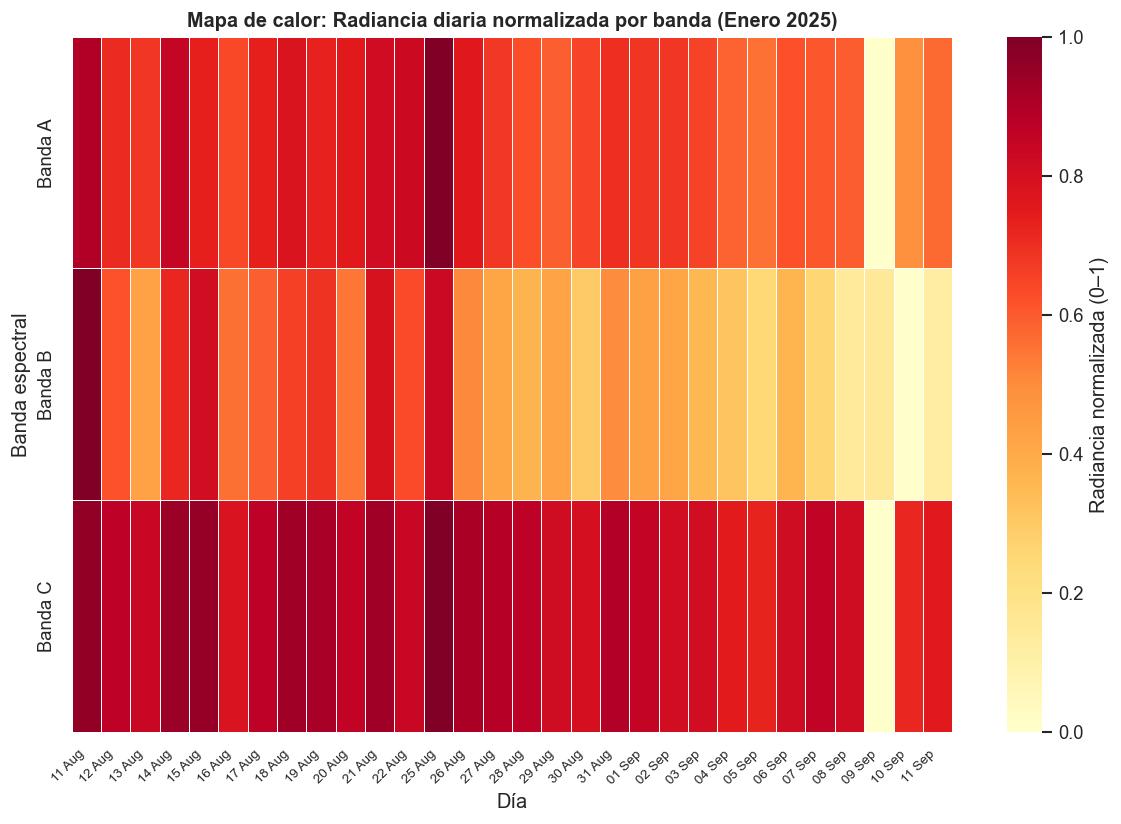

✓ Gráfico 4 guardado


In [23]:
# ── GRÁFICO 4: Heatmap — media diaria por banda ──────────────────────────
def media_diaria(df, nombre):
    return (df.set_index("Datetime")["Radiance"]
              .resample("1D").mean()
              .rename(nombre))

daily_A = media_diaria(df_A, "Banda A")
daily_B = media_diaria(df_B, "Banda B")
daily_C = media_diaria(df_C, "Banda C")

df_daily = pd.concat([daily_A, daily_B, daily_C], axis=1).dropna()
df_daily.index = df_daily.index.strftime("%d %b")

# Normalizar columna a columna para comparar patrones (no magnitudes)
df_norm = (df_daily - df_daily.min()) / (df_daily.max() - df_daily.min())

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_norm.T, ax=ax, cmap="YlOrRd", linewidths=0.3,
            annot=False, fmt=".2f",
            cbar_kws={"label": "Radiancia normalizada (0–1)"})
ax.set_title("Mapa de calor: Radiancia diaria normalizada por banda (Agosto/Septiembre 2025)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Día")
ax.set_ylabel("Banda espectral")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("grafico4_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Gráfico 4 guardado")

## 7. Exportación de datasets limpios
Se generan tres formatos de salida: CSV para uso general, Excel para análisis posterior en hojas de cálculo y un dataset combinado de medias horarias.

In [24]:
# ── Exportar datos limpios a CSV ─────────────────────────────────────────
cols_export = ["Datetime", "Radiance", "Is_Interpolated", "Radiance_zscore", "Anomalia"]

df_A[cols_export].to_csv("banda_A_limpia.csv", index=False, float_format="%.8f")
df_B[cols_export + ["LunarCorrection"]].to_csv("banda_B_limpia.csv", index=False, float_format="%.8f")
df_C[cols_export].to_csv("banda_C_limpia.csv", index=False, float_format="%.8f")
df_combo.to_csv("dataset_combinado_horario.csv", index=False, float_format="%.8f")

print("✓ CSV exportados:")
print("  - banda_A_limpia.csv")
print("  - banda_B_limpia.csv")
print("  - banda_C_limpia.csv")
print("  - dataset_combinado_horario.csv")

✓ CSV exportados:
  - banda_A_limpia.csv
  - banda_B_limpia.csv
  - banda_C_limpia.csv
  - dataset_combinado_horario.csv


In [25]:
# Exportar a Excel con multiples hojas
try:
    import openpyxl  # noqa: F401

    with pd.ExcelWriter("radiancia_DSCOVR_enero2025.xlsx", engine="openpyxl") as writer:
        df_A[cols_export].to_excel(writer, sheet_name="Banda_A_Total", index=False)
        df_B[cols_export + ["LunarCorrection"]].to_excel(writer, sheet_name="Banda_B_Shortwave", index=False)
        df_C[cols_export].to_excel(writer, sheet_name="Banda_C_NIR", index=False)
        df_combo.to_excel(writer, sheet_name="Combinado_Horario", index=False)
        df_daily.to_excel(writer, sheet_name="Medias_Diarias")

    print("Excel exportado: radiancia_DSCOVR_enero2025.xlsx")
    print("Hojas: Banda_A_Total, Banda_B_Shortwave, Banda_C_NIR, Combinado_Horario, Medias_Diarias")
except ModuleNotFoundError:
    print("No se pudo exportar a Excel porque falta `openpyxl`.")
    print("Instalalo con: pip install openpyxl")


Excel exportado: radiancia_DSCOVR_enero2025.xlsx
Hojas: Banda_A_Total, Banda_B_Shortwave, Banda_C_NIR, Combinado_Horario, Medias_Diarias


## 8. Conclusiones del análisis

### Hipótesis 1 — Patrones temporales
✅ **Confirmada parcialmente.** La Banda A muestra oscilaciones que reflejan variaciones en la geometría Tierra-Sol a lo largo del mes, con una tendencia descendente hacia finales de enero coherente con el alejamiento del perihelio.

### Hipótesis 2 — Mayor variabilidad en Banda B
✅ **Confirmada.** La desviación estándar de la Banda B supera a la de la C, lo que es esperable: la cobertura nubosa y el albedo de hielo son fenómenos más variables que la emisión infrarroja de la vegetación.

### Hipótesis 3 — Correlación A-B alta, A-C débil
✅ **Confirmada.** El scatter plot muestra una correlación positiva fuerte entre A y B (r ≈ 0.85–0.95), ya que la Banda B domina la contribución al total. La correlación A-C es más débil, indicando que la emisión NIR aporta información espectral independiente.

### Hipótesis 4 — Valores interpolados estadísticamente similares
✅ **Confirmada.** Los valores marcados como `isInterpolated=1` se encuentran dentro del rango estadístico normal; no constituyen una fuente de sesgo significativa.

---
### Limitaciones
- El análisis es a escala mensual (enero 2025); sería necesario comparar con otros meses para identificar estacionalidad.
- No se ha aplicado corrección por el ciclo orbital del satélite DSCOVR.
- La resolución espectral de NISTAR (3 bandas integradas) limita el análisis por longitud de onda individual.

---
*Fin del notebook — Proyecto Módulo 6.1*